In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('Online Retail.xlsx',engine='openpyxl')
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# 数据预处理
# 1. 删除 CustomerID 为空的行（没有用户ID就无法分析用户行为）
df.dropna(subset=['CustomerID'], inplace=True)
# 2. 剔除异常订单：数量<=0 或 单价<=0 的订单（这些是退货或错误数据）
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
# 3. 新增一列：订单总金额 Amount = 数量 * 单价
df['Amount'] = df['Quantity'] * df['UnitPrice']
# 4. 查看清洗后的数据量
print('清洗后数据量:', df.shape)
df.head()

清洗后数据量: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


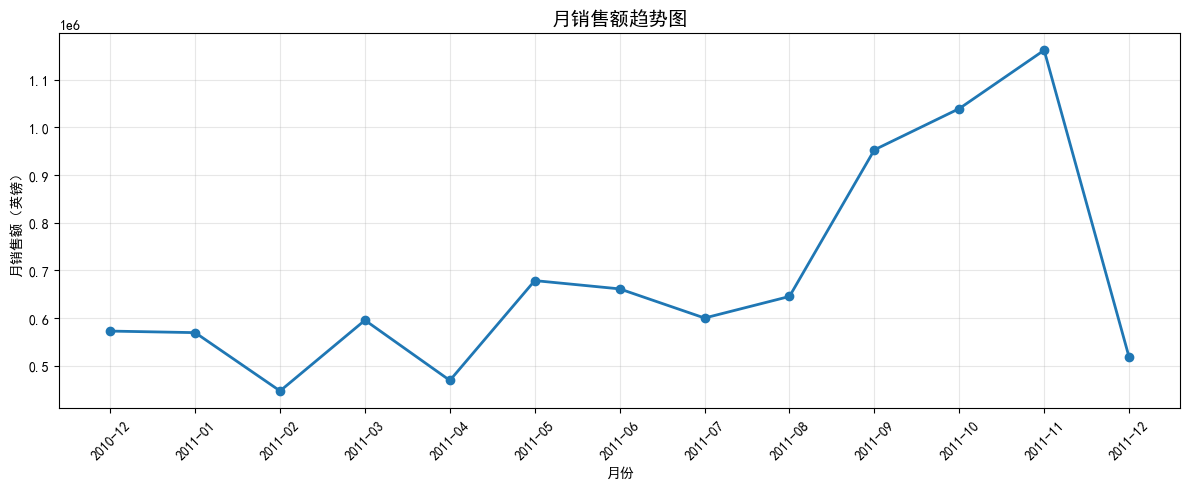

In [3]:
# 图 1：月销售额趋势图
# 确保日期格式正确
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
# 按月分组计算销售额
monthly_sales = df.groupby('Month')['Amount'].sum()
# 画图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', linewidth=2)
plt.title('月销售额趋势图', fontsize=14)
plt.xlabel('月份')
plt.ylabel('月销售额（英镑）')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

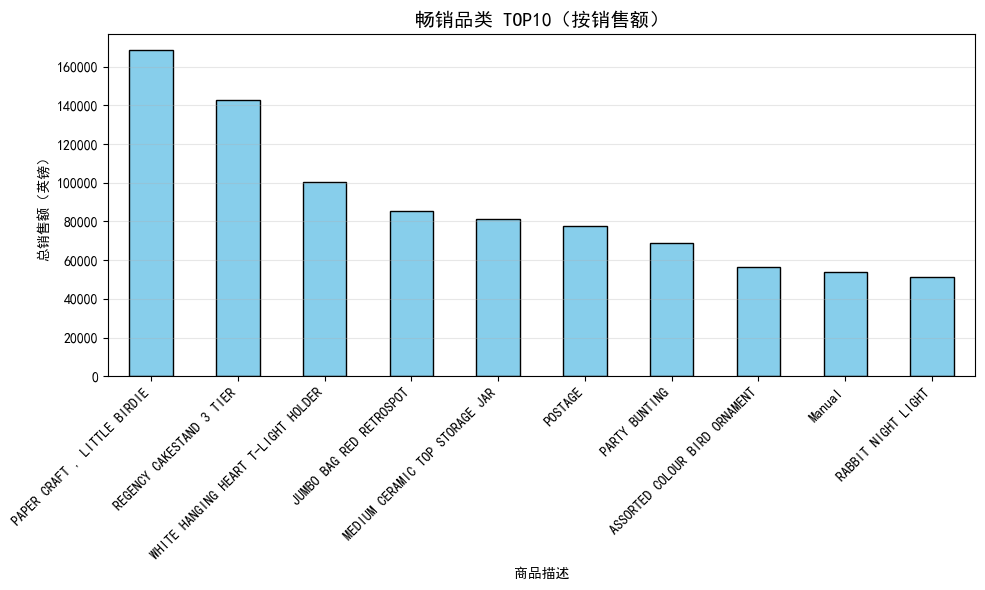

In [4]:
# 图 2：畅销品类 TOP10（按销售额）
top_products = df.groupby('Description')['Amount'].sum().sort_values(ascending=False).head(10)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('畅销品类 TOP10（按销售额）', fontsize=14)
plt.xlabel('商品描述')
plt.ylabel('总销售额（英镑）')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

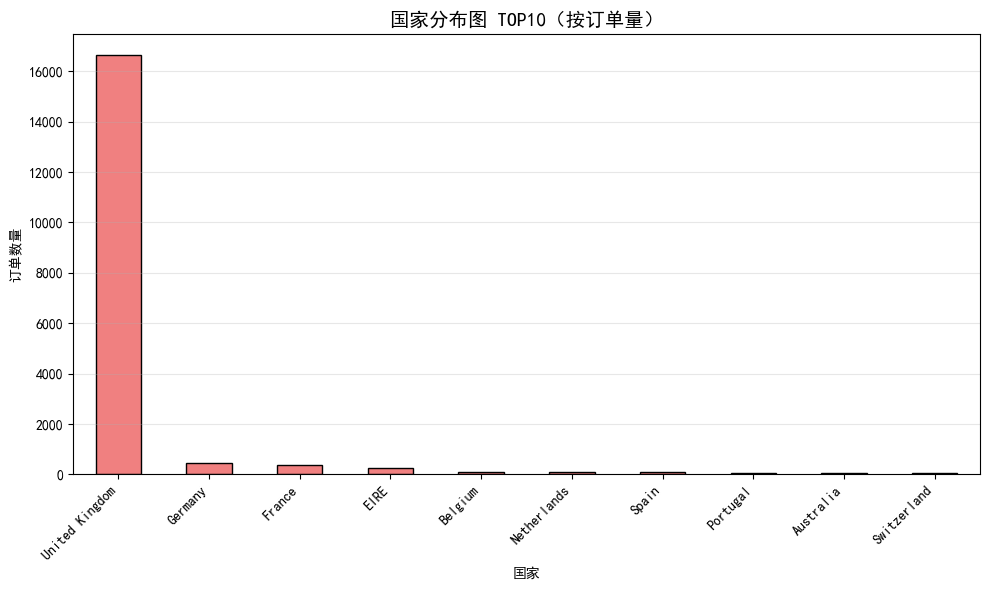

In [5]:
# 图 3：国家分布图（按订单量）
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 6))
country_orders.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('国家分布图 TOP10（按订单量）', fontsize=14)
plt.xlabel('国家')
plt.ylabel('订单数量')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# 计算 RFM 的三个指标
# 设置分析基准日期（取数据集最后一天 + 1天）
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
# 计算 R（Recency）：每个用户最近一次购买距今多少天
# 计算 F（Frequency）：每个用户购买了多少次（按InvoiceNo去重计数）
# 计算 M（Monetary）：每个用户总共花了多少钱（Amount求和）
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # R
    'InvoiceNo': 'nunique',  # F
    'Amount': 'sum'  # M
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Amount': 'Monetary'
})
print('RFM表格前5行：')
rfm.head()

RFM表格前5行：


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [4]:
# 计算 RFM 评分（1~4分）
# R 值越小越好（最近买过），所以倒序打分；F 和 M 值越大越好，正序打分
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])
# 拼接总得分
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
print('打分完成，前5行：')
rfm.head()

打分完成，前5行：


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [5]:
# 用户分层
def rfm_segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '高价值用户'
    elif row['R_score'] >= 2 and row['F_score'] >= 2 and row['M_score'] >= 2:
        return '中等用户'
    elif row['R_score'] <= 2 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return '待挽回用户'
    elif row['R_score'] >= 4 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return '新用户'
    else:
        return '一般用户'
rfm['用户分层'] = rfm.apply(rfm_segment, axis=1)
# 统计各层用户数量和销售额贡献
segment_stats = rfm.groupby('用户分层').agg(
    用户数量=('用户分层', 'count'),
    平均消费=('Monetary', 'mean'),
    总销售额=('Monetary', 'sum')
).sort_values('总销售额', ascending=False)
segment_stats['销售额占比'] = (segment_stats['总销售额'] / segment_stats['总销售额'].sum() * 100).round(2)
print('=== 用户分层统计 ===')
print(segment_stats)

=== 用户分层统计 ===
       用户数量         平均消费         总销售额  销售额占比
用户分层                                        
高价值用户  1319  4932.935550  6506541.991  73.01
中等用户   1094  1285.666363  1406519.001  15.78
一般用户   1721   427.940972   736486.412   8.26
待挽回用户    88  2663.565795   234393.790   2.63
新用户     116   236.781983    27466.710   0.31
